In [ ]:
# EDA — Bronze raw_transactions
# Cài trước: pip install -r requirements-gen.txt
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from pathlib import Path

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl (75 kB)
Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl (7.2 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# 1. Load all Bronze transaction partitions
tx = pd.concat(pd.read_parquet(f) for f in Path('../data/bronze/raw_transactions').glob('*.parquet'))
tx.shape

In [ ]:
# 2. Cast types for EDA only (do not overwrite Bronze)
tx['amount_num'] = pd.to_numeric(tx['amount'], errors='coerce')
tx['ts'] = pd.to_datetime(tx['transaction_time'], errors='coerce')
print('bad amount:', tx.amount_num.isna().sum(), 'bad ts:', tx.ts.isna().sum())
tx.isna().mean().round(4)  # null/parse-fail %

In [ ]:
# 3. Amount distribution (log-scale) by transaction type
sns.histplot(data=tx[tx.amount_num>0], x='amount_num', hue='transaction_type', log_scale=True, element='step')
plt.show()

In [ ]:
# 4. Transactions per day
tx.assign(d=tx.ts.dt.date).groupby('d').size().plot()
plt.show()

In [ ]:
# 5. Channel distribution + status mix + median amount by type
sns.countplot(data=tx, x='channel')
plt.show()
print(tx.status.value_counts(normalize=True))
print(tx.groupby('transaction_type').amount_num.median())

(2000000, 25)
transaction_id         0.0000
customer_id            0.0000
account_id             0.0000
merchant_id            0.0000
device_id              0.0000
card_id                0.0000
amount                 0.0000
currency               0.0000
transaction_type       0.0000
channel                0.0000
transaction_time       0.0000
country                0.0000
city                   0.0000
status                 0.0000
location_id            0.0000
ingestion_time         0.0000
source_system          0.0000
batch_id               0.0000
file_name              0.0000
source_row_number      0.0000
_source_file           0.0000
_batch_id              0.0000
_bronze_ingested_at    0.0000
amount_num             0.0023
ts                     0.0012
dtype: float64
bad amount 4666 bad ts 2500


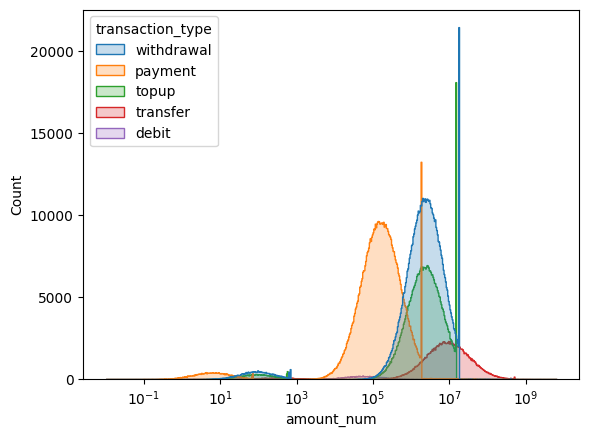

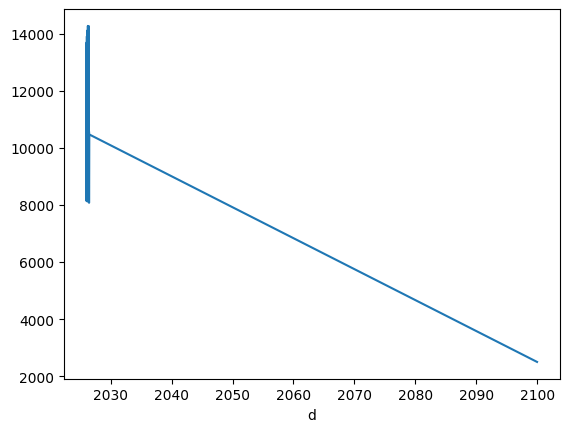

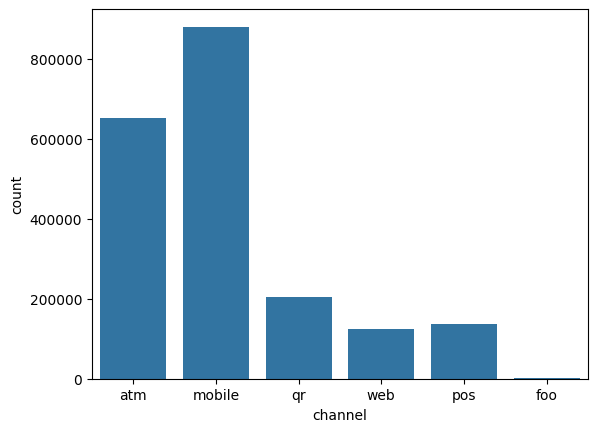

status
success    0.972043
failed     0.021926
pending    0.006031
Name: proportion, dtype: float64
transaction_type
debit           51697.300
payment        149480.400
topup         2158696.815
transfer      8333389.500
withdrawal    2236227.950
Name: amount_num, dtype: float64


In [ ]:
# (Code đã được tách thành các cell riêng ở trên)

## Nhận xét EDA — Bronze `raw_transactions` (2,000,000 dòng)

### Tổng quan
- 2M giao dịch, 25 cột. Mọi cột raw 0% null (Bronze giữ nguyên text, kể cả giá trị lỗi).
- ~0.23% amount không parse được (`"NaN"`, `"amount_unknown"`), ~0.12% timestamp lỗi (`"not_a_timestamp"`).
- Các lỗi này là chủ đích từ generator, sẽ được xử lý ở Silver/Quarantine (Day 7-8).

### Phân phối số tiền
- Log-normal lệch phải — đúng đặc trưng giao dịch tài chính, calibrate từ PaySim.
- Median theo loại khớp `paysim_params.json`.

### Kênh & trạng thái
- `mobile` chiếm ~50%, tiếp theo QR/POS/web/ATM.
- success 97.2% · failed 2.19% · pending 0.60%.

### Kết luận
Bronze đạt yêu cầu → sẵn sàng chuyển sang Silver.